# Lab: Ridge, Lasso, and PCR
## CMSE 381 - Spring 2022
## March 18, 2022



##ANSWER## 

Instructor notes:

Made use of this python translation of the lab: https://www.science.smith.edu/~jcrouser/SDS293/labs/lab10-py.html

and
https://www.science.smith.edu/~jcrouser/SDS293/labs/lab11-py.html

Note: needed to update the `Hitters.csv` file I found online to have the label `Player` in the first column


In this module we are going to test out the ridge/lasso methods we discussed in class from Chapter 6.2, and the PCR ideas from Chapter 6.3.

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time


# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# Loading in the data

Ok, here we go, let's play with a baseball data set again. Note this cleanup is all the same as the last lab. 

In [2]:
df = pd.read_csv('Hitters.csv').dropna().drop('Player', axis = 1)
df.info()
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64

In [3]:
y = df.Salary

# Drop the column with the independent variable (Salary), and columns for which we created dummy variables
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 1).astype('float64')

# Define the feature set X.
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)

X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    uint8  
 17  Division_W   263 non-null    uint8  
 18  NewLeague_N  263 non-null    uint8  
dtypes: float

# Ridge Regression

In class, we learned that doing ridge regression means that we try to find the best model accoding to the score
$$
RSS + \lambda \sum_{i} \beta_i^2.
$$
The good news is that `scikitlearn` has a built in `Ridge` function.  

- [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [User guide](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)

In [4]:
from sklearn.linear_model import Ridge

The bad (ok, not honestly that bad) news is that they call their $\lambda$ parameter $\alpha$. So we're just going to minimize 
$$
RSS + \alpha \sum_{i} \beta_i^2.
$$
instead. So if I pick an alpha value, I can do ridge regression as follows.

In [5]:
ridge = Ridge(normalize = True) 

a = 1 #<------ this is me picking an alpha value

ridge.set_params(alpha = a)
ridge.fit(X, y)

print('intercept:', ridge.intercept_)
print('\n')
print(pd.Series(ridge.coef_, index = X.columns))
print('\nTraining MSE:',mean_squared_error(y,ridge.predict(X)))
    


intercept: 26.66687828393964


AtBat           0.097980
Hits            0.767038
HmRun           0.893927
Runs            1.017932
RBI             0.875287
Walks           1.496945
Years           2.030631
CAtBat          0.011288
CHits           0.052696
CHmRun          0.376167
CRuns           0.105102
CRBI            0.110652
CWalks          0.064244
PutOuts         0.146147
Assists         0.022450
Errors         -1.057414
League_N       18.461672
Division_W    -68.848656
NewLeague_N     9.461254
dtype: float64

Training MSE: 110090.38711673138



&#9989; **<font color=red>Q:</font>** What is the `normalize=True` bit doing in the code above?

* Your answer here*

##ANSWER## 

This is standardizing the variables. There is a note in teh documentation about this being removed in 1.2 so should probably change this soon to use `sklearn.preprocessing.StandardScaler`. 

Of course, that was just me picking a random $\alpha$ out of a hat so there's no reason to trust that it's a good one. I could sit here all day and move that $\alpha$ around to see what's going on, but why do that, when I can make a for loop!

Here's a pile of $\alpha$s for us to test on.

In [6]:
alphas = 10**np.linspace(4,-2,100)*0.5
alphas = np.append(alphas,0)
alphas

array([5.00000000e+03, 4.34874501e+03, 3.78231664e+03, 3.28966612e+03,
       2.86118383e+03, 2.48851178e+03, 2.16438064e+03, 1.88246790e+03,
       1.63727458e+03, 1.42401793e+03, 1.23853818e+03, 1.07721735e+03,
       9.36908711e+02, 8.14875417e+02, 7.08737081e+02, 6.16423370e+02,
       5.36133611e+02, 4.66301673e+02, 4.05565415e+02, 3.52740116e+02,
       3.06795364e+02, 2.66834962e+02, 2.32079442e+02, 2.01850863e+02,
       1.75559587e+02, 1.52692775e+02, 1.32804389e+02, 1.15506485e+02,
       1.00461650e+02, 8.73764200e+01, 7.59955541e+01, 6.60970574e+01,
       5.74878498e+01, 5.00000000e+01, 4.34874501e+01, 3.78231664e+01,
       3.28966612e+01, 2.86118383e+01, 2.48851178e+01, 2.16438064e+01,
       1.88246790e+01, 1.63727458e+01, 1.42401793e+01, 1.23853818e+01,
       1.07721735e+01, 9.36908711e+00, 8.14875417e+00, 7.08737081e+00,
       6.16423370e+00, 5.36133611e+00, 4.66301673e+00, 4.05565415e+00,
       3.52740116e+00, 3.06795364e+00, 2.66834962e+00, 2.32079442e+00,
      

First off, let's take a look at how the coefficients learned change for various choices of $\alpha$. 

Associated with each alpha value is a vector of ridge regression coefficients, which we'll store in a matrix coefs. In this case, it is a  19×100  matrix, with 19 rows (one for each predictor) and 100 columns (one for each value of alpha). 

In [7]:
ridge = Ridge(normalize = True)
coefs = []

for a in alphas:
    ridge.set_params(alpha = a)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)
    
np.shape(coefs)

(101, 19)

Text(0, 0.5, 'weights')

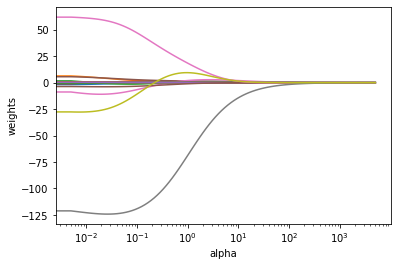

In [8]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')


&#9989; **<font color=red>Q:</font>** There are two variables that have higher magnitude than the rest for low $\alpha$s (read: are either very large positive or very large negative). Which two are they from the data set? Which is which?


In [9]:
# Your code here #

In [10]:
##ANSWER##

# Note the coefs matrix does alphas in decreasing order
# so we want the last entry
# 
# Also we want magnitude, so we want absolute value rather than 
# just the entries sorted. Could also just go outside in on the 
# argmax without the absolute value.
print(np.argmax(np.abs(coefs[-1])) )
# Location of top, but we want top 2.


print(np.abs(coefs[-1]).argsort()) 
# Locations of all entries, increasing order though

topCols = np.abs(coefs[-1]).argsort()[-2:] # Here's the last two 

print('The two highest values are from:')
top = list(df.columns[topCols])
print(top)

print('Entry 17:',df.columns[17],coefs[-1][17])
print('Entry 6:',df.columns[16],coefs[-1][16])

17
[ 8  7  9 13 14 11 12  4 10  0  3 15  6  2  5  1 18 16 17]
The two highest values are from:
['Assists', 'Errors']
Entry 17: Errors -116.8492456368761
Entry 6: Assists 62.59942303518346


Now we can start setting up the usual train/test splits to have at least a starting idea of how the testing error is going. The `random_state=1` bit just makes it so that everyone should get the same random split. 

In [11]:
# Split data into training and test sets
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


&#9989; **<font color=red>Do this:</font>** Train a model using ridge regression with $\alpha = 4$. What is the MSE of your model on the training set?

In [12]:
# Your code here #

In [13]:
##ANSWER##
ridge = Ridge(alpha = 1, normalize = True)
ridge.fit(X_train, y_train)             # Fit a ridge regression on the training data
pred = ridge.predict(X_test)           # Use this model to predict the test data
# print(pd.Series(ridge.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred))          # Calculate the test MSE

116097.78127989522



&#9989; **<font color=red>Do this:</font>** Ha ha nah, you can do better than that.  Lets try all our alphas and take a look at the testing MSE to make a better decision about what $\alpha$ we might want. Modify the code below to plot your testing MSE for all the alphas. What $\alpha$ should we use to train the model?

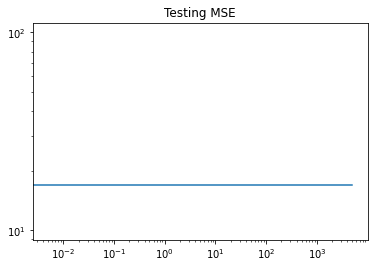

In [14]:
# Modify your code from above and add it in the for loop to plot the testing MSE

ridge = Ridge(normalize = True)
errors = []

for a in alphas:
    # ==== Your code goes in here ==== #
    errors.append(17) #<----- random number in here so that the code runs before you fix it
    
np.shape(errors)

plt.plot(alphas,errors)
plt.title('Testing MSE')
ax=plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')



Min occurs at alpha =  0.37823166377731454
Min MSE is 114444.82569240114


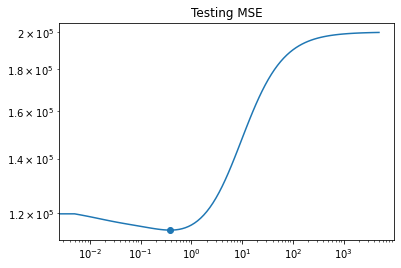

In [15]:
##ANSWER##

ridge = Ridge(normalize = True)
errors = []

for a in alphas:
    ridge.set_params(alpha = a)
    ridge.fit(X_train, y_train) 
    pred = ridge.predict(X_test) 
    errors.append(mean_squared_error(y_test,pred))
    
np.shape(errors)

i = np.argmin(errors) # Index of minimum 

plt.title('Testing MSE')

plt.plot(alphas,errors)
plt.scatter(alphas[i],errors[i])
ax=plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

print('Min occurs at alpha = ', alphas[i])
print('Min MSE is', errors[i])



## RidgeCV

Whelp, your meanie professor didn't tell you that there's actually a built in function to do this for you (sorry-not-sorry). Aren't you glad you didn't read ahead?


In [16]:
from sklearn.linear_model import RidgeCV

- [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)
- [User Guide](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)

Basically, `RidgeCV` runs LOOCV (unless you tell it otherwise, see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)) on all the alpha values you specify on an input array, and tells you the best $\alpha$ given that. 

In [17]:
# I'm going to drop that 0 from the alphas because it makes 
# RidgeCV cranky
alphas = alphas[:-1]


ridgecv = RidgeCV(alphas = alphas, 
                  scoring = 'neg_mean_squared_error', 
                  normalize = True)
ridgecv.fit(X_train, y_train)
print('alpha chosen is', ridgecv.alpha_)

alpha chosen is 0.008737642000038414


I can predict my values on the test set directly from the `ridgecv` model we just built. 

In [18]:
pred = ridgecv.predict(X_test)
mean_squared_error(y_test,pred)

119041.82784985412

This is exactly the same result as if I went and retrained my model using the chosen $\alpha$ using `Ridge`. 

In [19]:
ridge = Ridge(alpha = ridgecv.alpha_, normalize = True)
ridge.fit(X_train, y_train)
mean_squared_error(y_test, ridge.predict(X_test))

119041.82784991188

&#9989; **<font color=red>Do this:</font>** Why did we get a different best choice of $\alpha$ than we found in the previous section? 

*Your answer here*

##ANSWER##

We're not doing exaclty the same thing in both sections. We didn't do LOOCV in the previous section, just validation set.  But looking at the MSE resulting from both, it's not a huge difference.

# Lasso 

Thanks to the wonders of `scikit-learn`, now that we know how to do all this with ridge regression, translation to lasso is super easy. 

- [Lasso Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
- [LassoCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html#sklearn.linear_model.LassoCV)
- [User guide](https://scikit-learn.org/stable/modules/linear_model.html#lasso)



##ANSWER##
Note for next year: issues with deprecation of normalization likely to pop up. I'm leaving the modified version in here in the answers, but this should be modified to be included in the previous section

In [20]:
from sklearn.linear_model import Lasso, LassoCV

In [22]:
# Here's a quick lasso code for a fixed $\alpha$
lasso = Lasso(max_iter = 10000, normalize = True)
# max_iter increases how long the lasso model tries to find a good solution
# In our case, if I leave it at the default 1000 I was getting errors, so I
# upped the value. 
lasso.set_params(alpha=1)
lasso.fit(X_train, y_train)

mean_squared_error(y_test,lasso.predict(X_test))


116062.29382417377

&#9989; **<font color=red>Do this:</font>** Make a few graphs similar to what we did in the previous section, but using Lasso instead of Ridge. 
- A graph of the coeffiencts as alpha changes 
- A graph of the test mean squared error as alpha changes

In [23]:
# Your code for a graph of the coefficients goes here 

In [24]:
# Your code for a graph of the MSEs goes here

Text(0, 0.5, 'weights')

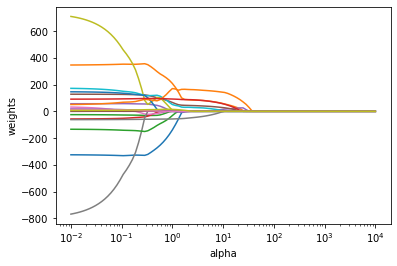

In [25]:
##ANSWER##

from sklearn.preprocessing import scale 


lasso = Lasso(max_iter = 10000, normalize = True)
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(scale(X_train), y_train)
    coefs.append(lasso.coef_)
    
ax = plt.gca()
ax.plot(alphas*2, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')


Min occurs at alpha =  0.5748784976988678
Min MSE is 115073.14750054802


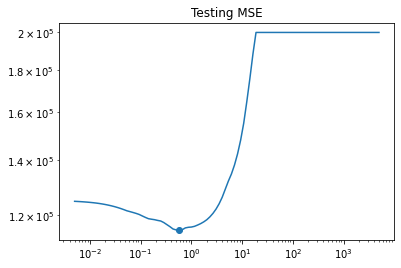

In [26]:
##ANSWER##


lasso = Lasso(max_iter = 10000, normalize = True)
errors = []

for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X_train, y_train) 
    pred = lasso.predict(X_test) 
    errors.append(mean_squared_error(y_test,pred))
    
np.shape(errors)

i = np.argmin(errors) # Index of minimum 

plt.title('Testing MSE')

plt.plot(alphas,errors)
plt.scatter(alphas[i],errors[i])
ax=plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

print('Min occurs at alpha = ', alphas[i])
print('Min MSE is', errors[i])

&#9989; **<font color=red>Do this:</font>** Now try what we did with `LassoCV`.  What choice of $\alpha$ does it recommend? 

*I would actually recommend either not passing in any $\alpha$ list or passing explicitly `alphas = None`. `RidgeCV` can't do this, but `LassoCV` will automatically try to find good choices of $\alpha$ for you.*

In [27]:
# Your code here

In [28]:
##ANSWER##

lassocv = LassoCV(max_iter = 10000, normalize = True)
lassocv.fit(X_train, y_train)
print('alpha = ', lassocv.alpha_)
print('MSE = ', mean_squared_error(y_test, lassocv.predict(X_test)))

alpha =  0.08537737278171939
MSE =  120469.50106233472


Now let's take a look at some of the coefficients. 

In [29]:
# Some of the coefficients are now reduced to exactly zero.
pd.Series(lassocv.coef_, index=X.columns)

AtBat           -2.247474
Hits             7.743762
HmRun           -3.359537
Runs            -1.875578
RBI              2.162306
Walks            5.516630
Years           -0.000000
CAtBat          -0.143677
CHits            0.503013
CHmRun           1.643711
CRuns            0.368373
CRBI             0.209216
CWalks          -0.516082
PutOuts          0.322087
Assists          0.066260
Errors           0.064568
League_N        16.887422
Division_W    -121.286305
NewLeague_N     19.049495
dtype: float64

&#9989; **<font color=red>Q:</font>** We've been repeating over and over that lasso gives us coefficients that are actually 0.  At least in my code, I'm not seeing any that are 0. What happened?

*Your answer here*

In [30]:
# You might also want some code in here to try to figure it out

In [31]:
##ANSWER##

# You need to have a higher alpha than what was found with the CV to start getting 0 
# entries for the coefficients
lasso = Lasso(max_iter = 10000, normalize = True)
coefs = []

a = 10
lasso.set_params(alpha=a)
lasso.fit(scale(X_train), y_train)


pd.Series(lasso.coef_, index=X.columns)

AtBat           0.000000
Hits           24.287066
HmRun           0.000000
Runs            0.000000
RBI            24.164759
Walks           6.210044
Years           0.000000
CAtBat          0.000000
CHits           0.000000
CHmRun          0.000000
CRuns           0.000000
CRBI           94.892292
CWalks          0.000000
PutOuts        12.937782
Assists        -0.000000
Errors          0.000000
League_N       -0.000000
Division_W     -0.000000
NewLeague_N    -0.000000
dtype: float64

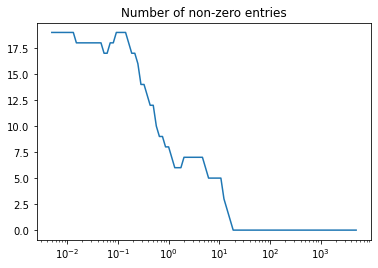

In [32]:
##ANSWER## 

# Here's a graph of the number of non-zero entries for different choices of alpha

lasso = Lasso(max_iter = 10000, normalize = True)
nonzero = []

for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X_train, y_train) 
    nonzero.append(np.count_nonzero(lasso.coef_)) #Counts the number of non-0 entries
    



plt.title('Number of non-zero entries')

plt.plot(alphas,nonzero)
ax=plt.gca()
ax.set_xscale('log')




##ANSWER##
Toy data sets to try maybe? https://archive.ics.uci.edu/ml/index.php

# Principal Component Regression 

Ok, let's take a hard left turn and go try out some of the dimension reduction methods from Section 6.3. `Scikit-learn` doesn't have a built in function to do PCR (aka PCA and then regression) but it's just as easy for us to do it ourselves. 

First step, let's figure out the `PCA` function.

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale #<--- this does the scaling of variables for us


In [34]:
pca = PCA()
print(X.shape)
X_reduced = pca.fit_transform(scale(X))
print(X_reduced.shape)

(263, 19)
(263, 19)


"But Dr. Munch, you said PCA was supposed to do dimension reduction, why is my feature output the same size?"

Glad you asked, young data scientist. The PCA command outputs all of the PCs, all the way up through $p=19$ the original number of dimensions. 

So, if I want the first three PCs, I can get them out as follows. I'll put it in a data frame just to add column labels, but you don't need to do that.

In [35]:
First3PCs = X_reduced[:,:3]

pd.DataFrame(First3PCs, columns = ['Z1','Z2', 'Z3'])

,Z1,Z2,Z3
0,-0.009649,1.870522,1.265145
1,0.411434,-2.429422,-0.909193
2,3.466822,0.825947,0.555469
3,-2.558317,-0.230984,0.519642
4,1.027702,-1.573537,1.331382
...,...,...,...
258,-0.331167,-0.165663,0.775890
259,3.246183,-0.543315,1.209150
260,-1.094609,-0.751386,-0.935937
261,1.977682,-2.184517,-0.282012


In [36]:
pd.DataFrame(np.array(X)[:,:3], columns = ['X1','X2', 'X3'])

,X1,X2,X3
0,315.0,81.0,7.0
1,479.0,130.0,18.0
2,496.0,141.0,20.0
3,321.0,87.0,10.0
4,594.0,169.0,4.0
...,...,...,...
258,497.0,127.0,7.0
259,492.0,136.0,5.0
260,475.0,126.0,3.0
261,573.0,144.0,9.0


Now we can just do regression on the PCs like before. 

In [37]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_reduced[:,:3], y)
mean_squared_error(y,regr.predict(X_reduced[:,:3]))

117234.531905816

&#9989; **<font color=red>Do this:</font>** My code above contains the rookie mistake of only reporting training error. Write modified code to return the 10-fold CV error of linear regression on the first 3 PCs.

In [38]:
# Your code here #



# Hint: while not necessary, the following command might make 
# for some massively shortened code
from sklearn.model_selection import cross_val_score


In [39]:
##ANSWER##
i = 3
allCVs = -1*cross_val_score(regr, X_reduced[:,:i], y, cv=10, scoring='neg_mean_squared_error')
avgCV = allCVs.mean()
print(avgCV)

# Note 'neg_mean_squared_error' returns the negative of the MSE. Otherwise, the defaul
# is to return the default score for the linear regression above, which uses R^2
# as the default. 
# See https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score


125936.4971858609


&#9989; **<font color=red>Do this:</font>** Take the code you figured out above to get the score for 10-fold CV on the first 3 PCs, and include it in the for-loop below to see how the MSE changes as the number of PCs you use changes. 

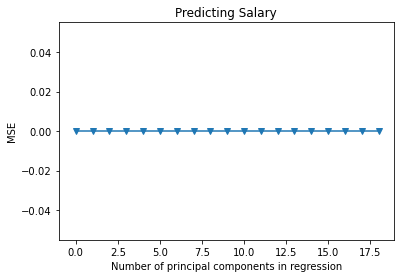

In [40]:
n = len(X_reduced)
regr = LinearRegression()
mse = []

# Calculate MSE using CV for the 19 principle components, adding one component at a time.
for i in np.arange(1, 20): # i is the number of principal components to use each time
    # ====
    score = 0 # Your code from above goes here!
    # ====

    mse.append(score)
    
# Plot results    
plt.plot(mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Predicting Salary')
plt.xlim(xmin=-1);

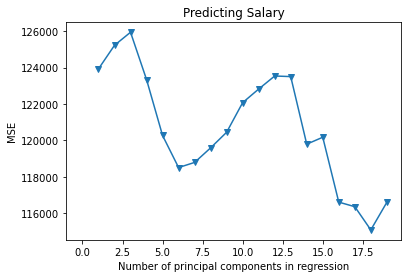

In [41]:
##ANSWER##


# 10-fold CV, no shuffle because cross_val_score doesn't include shuffle=True internally
n = len(X_reduced)

regr = LinearRegression()
mse = []

# Calculate MSE using CV for the 19 principle components, adding one component at the time.
for i in np.arange(1, 20):
    score = -1*cross_val_score(regr, X_reduced[:,:i], y.ravel(), cv=10, scoring='neg_mean_squared_error').mean()
    mse.append(score)
    
# Plot results    
plt.plot(np.arange(1, 20),mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Predicting Salary')
plt.xlim(xmin=-1);

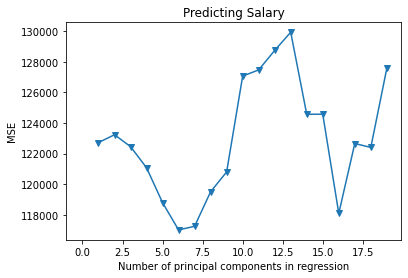

In [44]:
##ANSWER##

from sklearn.model_selection import KFold

# 10-fold CV, with shuffle that just makes things more complicated.
n = len(X_reduced)
kf_10 = KFold( n_splits=10, shuffle=True, random_state=48864)

regr = LinearRegression()
mse = []

# Calculate MSE with only the intercept (no principal components in regression)
# score = -1*model_selection.cross_val_score(regr, np.ones((n,1)), y.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()    
# mse.append(score)

# Calculate MSE using CV for the 19 principle components, adding one component at the time.
for i in np.arange(1, 20):
    score = -1*cross_val_score(regr, X_reduced[:,:i], y.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(score)
    
# Plot results    
plt.plot(np.arange(1, 20),mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Predicting Salary')
plt.xlim(xmin=-1);

&#9989; **<font color=red>Q:</font>** Based on the graph you generated above, how many PCs do you think you should use? 

*Note: Based on graphs I generated, I can see a few different options for what I might decide to use for number of principal components. This is one of those cases where you potentially have a different answer and/or reasoning from your neighbor, so I enourage you to talk this one through with your group.*


*Your answer here*

##ANSWER##

Depending on how I set the random state, either around 6 has lowest MSE, or something close to all ($m=$ 16, 17, or 18). Even when the higher values have the lowest MSE, 6 is comparable enough to argue that the lower dimension is worth it.

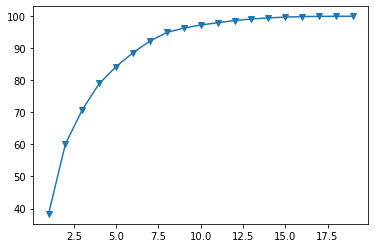

In [45]:
##ANSWER

# Leaving this code down here since might want it later, but we didn't discuss this 
# in class so thinking we just drop it.
varExplained = np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)

plt.plot(np.arange(1, 20),varExplained, '-v')

&#9989; **<font color=red>Q:</font>** Of the models you've built so far (Ridge, Lasso, and PCR), which would you choose to use and why? 

*Note: This goes in the no-one-right-answer bucket. Go argue with your group.*


*Your answer here*

##ANSWER##

- MSE for the three models are
  * RidgeCV 119041.82784991188
  * LassoCV 120469.50106233472
  * PCR 117500 (ish)
- PCR is lowest (at least for me). 
- Could argue for ridge or lasso to improve interpretability 

# Principal Least Squares (PLS)

Just for completeness, here's code to do PLS. `Scikit-learn` `PLSRegression` gives the same results as the `pls` package in R when using `method='oscorespls'`. However, the standard method used in `sklearn` is `'kernelpls'`, which we'll use here. 

In [49]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold

(-1.0, 19.9)

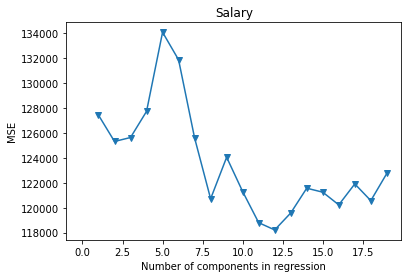

In [51]:
n = len(X_train)

# 10-fold CV, with shuffle
kf_10 = KFold(n_splits=10, shuffle=True, random_state=48864)

mse = []

for i in np.arange(1, 20):
    pls = PLSRegression(n_components=i)
    score = cross_val_score(pls, X_train, y_train, cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(-score)

# Plot results
plt.plot(np.arange(1, 20), np.array(mse), '-v')
plt.xlabel('Number of components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)

&#9989; **<font color=red>Q:</font>** After seeing the results of PLS, would you change your previous answer to the choice of model to use? Why or why not?

*Your answer here*


# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [52]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Part7-RidgeLassoPCA-INSTRUCTOR.ipynb


Lab-Part7_RidgeLassoPCA.ipynb


Validating Notebook ./Lab-Part7_RidgeLassoPCA.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


5